In [1]:
import pandas as pd
import pypsa

RESULT_FILE = "tamil_nadu_2025_26_15min.nc"
n = pypsa.Network(RESULT_FILE)

assert len(n.snapshots) == 672, f"Expected 672 quarter-hour snapshots, found {len(n.snapshots)}"
assert (n.snapshots.to_series().diff().dropna() == pd.Timedelta(minutes=15)).all()
assert (n.snapshot_weightings[["objective", "stores", "generators"]] == 0.25).all().all()
print(f"Loaded solved 15-minute peak week from {RESULT_FILE}")

INFO:pypsa.network.io:Imported network 'Tamil Nadu FY 2025-26 single-node UC inputs (15-minute)' has buses, carriers, generators, loads, storage_units, sub_networks


Loaded solved 15-minute peak week from tamil_nadu_2025_26_15min.nc


In [2]:
n

PyPSA Network 'Tamil Nadu FY 2025-26 single-node UC inputs (15-minute)'
-----------------------------------------------------------------------
Components:
 - Bus: 1
 - Carrier: 12
 - Generator: 278
 - Load: 1
 - StorageUnit: 4
 - SubNetwork: 1
Snapshots: 672

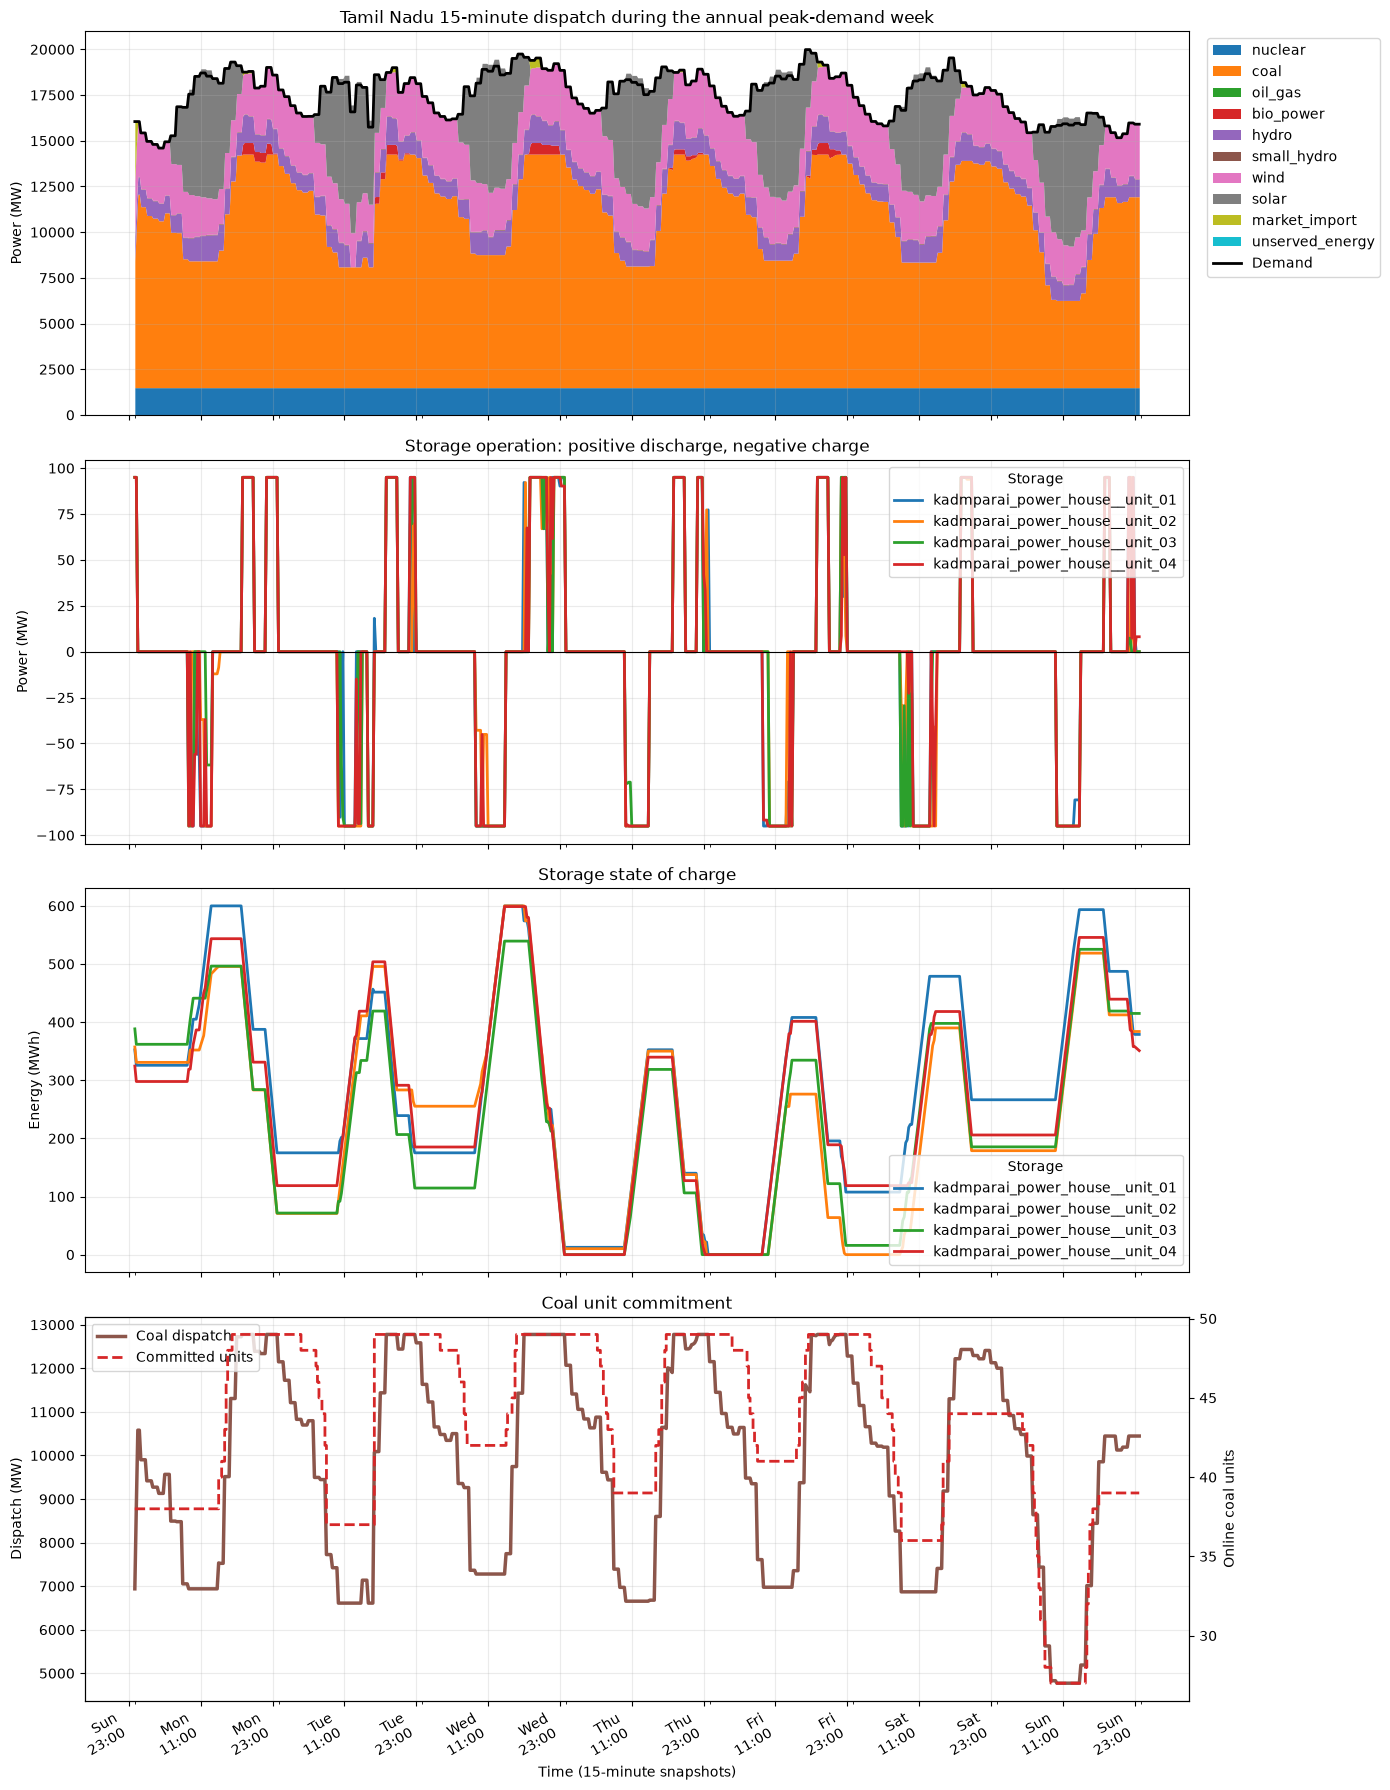

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

n

# Aggregate generator dispatch by carrier
generation = (
    n.generators_t.p
    .T.groupby(n.generators["carrier"])
    .sum().T
    .clip(lower=0)
)

# Storage: positive = discharge, negative = charge
storage_power = n.storage_units_t.p
storage_discharge = (
    storage_power.clip(lower=0)
    .T.groupby(n.storage_units["carrier"])
    .sum().T
)

supply = generation.add(storage_discharge, fill_value=0)
demand = n.loads_t.p_set.sum(axis=1)

carrier_order = [
    "nuclear", "coal", "oil_gas", "bio_power", "hydro",
    "small_hydro", "wind", "solar", "market_import",
    "battery", "unserved_energy",
]
carrier_order = [c for c in carrier_order if c in supply.columns]
supply = supply[carrier_order]

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

# 1. Total system dispatch
supply.plot.area(ax=axes[0], stacked=True, linewidth=0, x_compat=True)
demand.plot(
    ax=axes[0], color="black", linewidth=2, label="Demand", x_compat=True
)
axes[0].set_title("Tamil Nadu 15-minute dispatch during the annual peak-demand week")
axes[0].set_ylabel("Power (MW)")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1))

# 2. Storage charge and discharge
storage_power.plot(ax=axes[1], linewidth=2, x_compat=True)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Storage operation: positive discharge, negative charge")
axes[1].set_ylabel("Power (MW)")
axes[1].legend(title="Storage")

# 3. Storage state of charge
soc = n.storage_units_t.state_of_charge
soc.plot(ax=axes[2], linewidth=2, x_compat=True)
axes[2].set_title("Storage state of charge")
axes[2].set_ylabel("Energy (MWh)")
axes[2].legend(title="Storage")

# 4. Coal dispatch and committed record-level units
coal_units = n.generators.index[n.generators.carrier == "coal"]
coal_dispatch = n.generators_t.p[coal_units].sum(axis=1)
coal_online = n.generators_t.status[coal_units].sum(axis=1)

coal_dispatch.plot(
    ax=axes[3], color="tab:brown", linewidth=2.5,
    label="Coal dispatch", zorder=3, x_compat=True,
)
axes[3].set_title("Coal unit commitment")
axes[3].set_ylabel("Dispatch (MW)")

commitment_axis = axes[3].twinx()
coal_online.plot(
    ax=commitment_axis, drawstyle="steps-post", color="tab:red",
    linewidth=2, linestyle="--", label="Committed units",
    zorder=4, x_compat=True,
)
commitment_axis.set_ylabel("Online coal units")

lines1, labels1 = axes[3].get_legend_handles_labels()
lines2, labels2 = commitment_axis.get_legend_handles_labels()
axes[3].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

axes[3].xaxis.set_major_locator(mdates.HourLocator(interval=12))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
axes[3].set_xlabel("Time (15-minute snapshots)")
axes[3].grid(alpha=0.25)

for ax in axes[:3]:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Evening flexibility and ramp adequacy

Net load is demand minus wind and solar generation. Its increase between consecutive snapshots is the response that dispatchable generators and storage must provide. For committable generators, the calculation below reproduces PyPSA's applicable upward-ramp allowance: the normal ramp limit for units already online and the start-up ramp limit for units starting in that interval.

> **Resolution limitation:** the supplied demand and renewable availability are constant within each group of four quarter-hours and change only on the hour. Consequently, an entire hourly change occurs at one 15-minute boundary. The resulting MW/15-minute ramps are a conservative step-change stress test, not observed intra-hour variability. True 15-minute demand and renewable profiles are required for an empirical flexibility assessment.

In [4]:
vre_carriers = ["solar", "wind"]
dispatchable_carriers = [
    "coal", "oil_gas", "bio_power", "hydro",
    "small_hydro", "market_import",
]

generation_by_carrier = (
    n.generators_t.p.T.groupby(n.generators.carrier).sum().T.clip(lower=0)
)
vre_generation = generation_by_carrier.reindex(columns=vre_carriers, fill_value=0).sum(axis=1)
net_load = demand - vre_generation
net_load_ramp = net_load.diff()  # MW change between consecutive 15-minute averages

dispatchable_generation = generation_by_carrier.reindex(
    columns=dispatchable_carriers, fill_value=0
).sum(axis=1)
storage_response = n.storage_units_t.p.sum(axis=1)
dispatchable_response = dispatchable_generation + storage_response
dispatchable_response_ramp = dispatchable_response.diff()

# Reconstruct the exact upward allowance used for fixed-capacity committable units.
ramp_units = n.generators.index[
    n.generators.committable & n.generators.ramp_limit_up.notna()
]
unit_dispatch = n.generators_t.p[ramp_units]
unit_status = n.generators_t.status[ramp_units].round()
previous_dispatch = unit_dispatch.shift(1)
previous_status = unit_status.shift(1)
unit_increase = unit_dispatch - previous_dispatch
status_change = unit_status - previous_status

p_nom = n.generators.loc[ramp_units, "p_nom"]
normal_up = n.generators.loc[ramp_units, "ramp_limit_up"]
start_up = n.generators.loc[ramp_units, "ramp_limit_start_up"]
allowed_up = (
    previous_status.mul(p_nom * normal_up, axis=1)
    + status_change.mul(p_nom * start_up, axis=1)
)
upward_ramp_utilization = unit_increase.where(unit_increase > 1e-6).div(
    allowed_up.where(allowed_up > 0)
)
binding_up_units = upward_ramp_utilization.ge(0.95).sum(axis=1)
starting_units = status_change.gt(0.5).sum(axis=1)
max_up_utilization = upward_ramp_utilization.max(axis=1).clip(upper=1.0)

unserved = generation_by_carrier.get(
    "unserved_energy", pd.Series(0.0, index=n.snapshots)
)
unserved_mwh = (unserved * n.snapshot_weightings.generators).sum()
evening = net_load_ramp.index.hour.isin(range(15, 22))
peak_ramp_time = net_load_ramp.loc[evening].idxmax()

print(f"Largest evening net-load increase: {net_load_ramp.at[peak_ramp_time]:,.1f} MW/15 min "
      f"({4 * net_load_ramp.at[peak_ramp_time]:,.1f} MW/h equivalent) at {peak_ramp_time}")
print(f"Dispatchable response in that interval: "
      f"{dispatchable_response_ramp.at[peak_ramp_time]:,.1f} MW")
print(f"Thermal units starting: {starting_units.at[peak_ramp_time]:.0f}; "
      f"at or above 95% of upward ramp allowance: {binding_up_units.at[peak_ramp_time]:.0f}")
print(f"Unserved energy over the week: {unserved_mwh:,.3f} MWh")
print("Demand changes away from hourly boundaries:",
      int((demand.diff().abs() > 1e-9)[demand.index.minute != 0].sum()))
print("Solar/wind changes away from hourly boundaries:",
      int((vre_generation.diff().abs() > 1e-9)[vre_generation.index.minute != 0].sum()))

Largest evening net-load increase: 4,252.1 MW/15 min (17,008.3 MW/h equivalent) at 2025-07-08 16:00:00
Dispatchable response in that interval: 4,252.1 MW
Thermal units starting: 47; at or above 95% of upward ramp allowance: 84
Unserved energy over the week: 0.000 MWh
Demand changes away from hourly boundaries: 0
Solar/wind changes away from hourly boundaries: 0


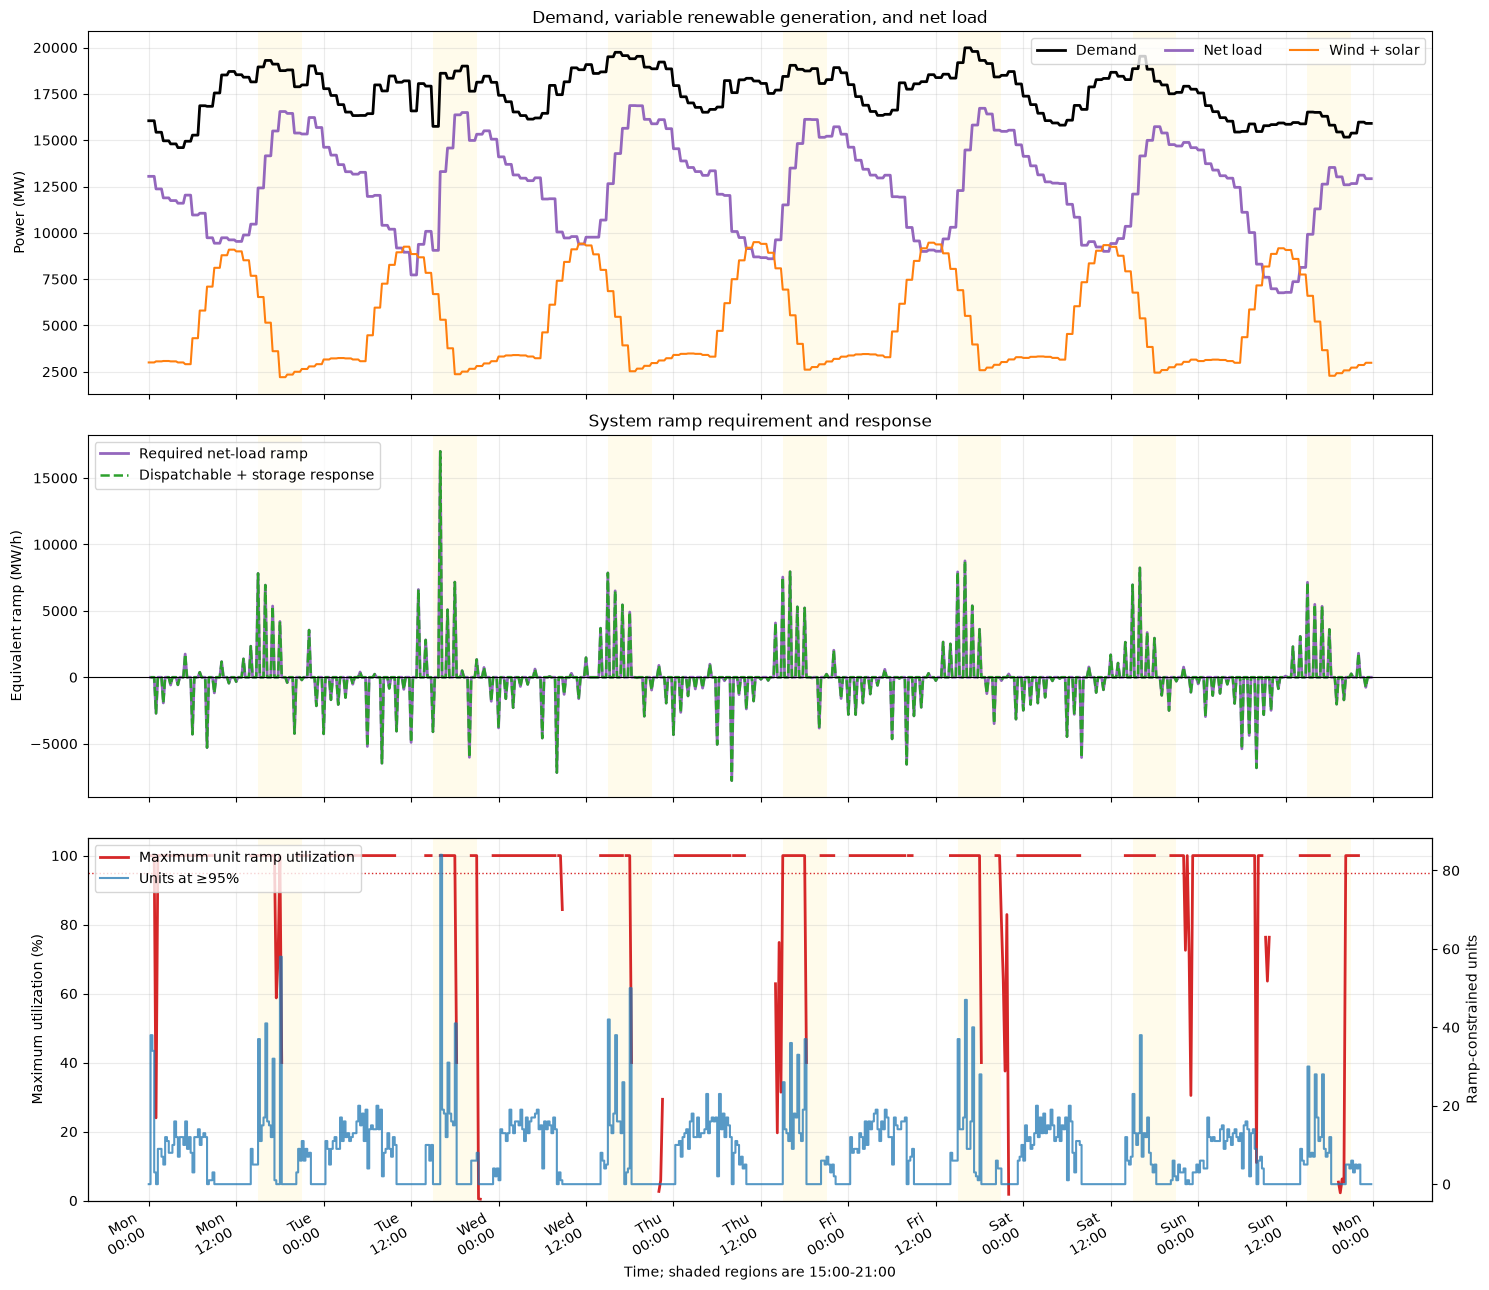

In [5]:
fig, ramp_axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)

demand.plot(ax=ramp_axes[0], color="black", linewidth=2, label="Demand", x_compat=True)
net_load.plot(ax=ramp_axes[0], color="tab:purple", linewidth=2, label="Net load", x_compat=True)
vre_generation.plot(ax=ramp_axes[0], color="tab:orange", label="Wind + solar", x_compat=True)
ramp_axes[0].set_ylabel("Power (MW)")
ramp_axes[0].set_title("Demand, variable renewable generation, and net load")
ramp_axes[0].legend(ncol=3)

(4 * net_load_ramp).plot(
    ax=ramp_axes[1], color="tab:purple", linewidth=2,
    label="Required net-load ramp", x_compat=True,
)
(4 * dispatchable_response_ramp).plot(
    ax=ramp_axes[1], color="tab:green", linestyle="--", linewidth=1.8,
    label="Dispatchable + storage response", x_compat=True,
)
ramp_axes[1].axhline(0, color="black", linewidth=0.8)
ramp_axes[1].set_ylabel("Equivalent ramp (MW/h)")
ramp_axes[1].set_title("System ramp requirement and response")
ramp_axes[1].legend()

(100 * max_up_utilization).plot(
    ax=ramp_axes[2], color="tab:red", linewidth=2,
    label="Maximum unit ramp utilization", x_compat=True,
)
ramp_axes[2].axhline(95, color="tab:red", linestyle=":", linewidth=1)
ramp_axes[2].set_ylim(0, 105)
ramp_axes[2].set_ylabel("Maximum utilization (%)")
binding_axis = ramp_axes[2].twinx()
binding_up_units.plot(
    ax=binding_axis, color="tab:blue", drawstyle="steps-post",
    alpha=0.75, label="Units at ≥95%", x_compat=True,
)
binding_axis.set_ylabel("Ramp-constrained units")

for day in pd.DatetimeIndex(n.snapshots.normalize().unique()):
    for ax in ramp_axes:
        ax.axvspan(
            day + pd.Timedelta(hours=15), day + pd.Timedelta(hours=21),
            color="gold", alpha=0.08, linewidth=0,
        )
for ax in ramp_axes:
    ax.grid(alpha=0.25)

lines1, labels1 = ramp_axes[2].get_legend_handles_labels()
lines2, labels2 = binding_axis.get_legend_handles_labels()
ramp_axes[2].legend(lines1 + lines2, labels1 + labels2, loc="upper left")
tick_positions = pd.date_range(
    n.snapshots[0].normalize(), n.snapshots[-1].ceil("12h"), freq="12h"
)
ramp_axes[2].set_xticks(tick_positions)
ramp_axes[2].set_xticklabels([timestamp.strftime("%a\n%H:%M") for timestamp in tick_positions])
ramp_axes[2].set_xlabel("Time; shaded regions are 15:00-21:00")
plt.tight_layout()
plt.show()

In [6]:
carrier_ramps = generation_by_carrier.reindex(
    columns=dispatchable_carriers, fill_value=0
).diff()
interval_summary = pd.DataFrame({
    "net_load_ramp_mw_per_15min": net_load_ramp,
    "equivalent_mw_per_hour": 4 * net_load_ramp,
    "dispatchable_response_mw": dispatchable_response_ramp,
    "coal_response_mw": carrier_ramps["coal"],
    "oil_gas_response_mw": carrier_ramps["oil_gas"],
    "bio_power_response_mw": carrier_ramps["bio_power"],
    "hydro_response_mw": carrier_ramps["hydro"],
    "storage_response_mw": storage_response.diff(),
    "thermal_startups": starting_units,
    "units_at_or_above_95pct_ramp": binding_up_units,
    "unserved_energy_mw": unserved,
})

print("Largest late-afternoon/evening system ramps:")
display(interval_summary.loc[evening].nlargest(10, "net_load_ramp_mw_per_15min").round(2))

unit_events = pd.DataFrame({
    "actual_increase_mw": unit_increase.stack(),
    "allowed_increase_mw": allowed_up.stack(),
    "ramp_utilization": upward_ramp_utilization.stack(),
}).dropna()
unit_events = unit_events.loc[unit_events.actual_increase_mw > 1e-6].reset_index()
unit_events.columns = ["snapshot", "generator", *unit_events.columns[2:]]
unit_events["carrier"] = unit_events.generator.map(n.generators.carrier)
unit_events["started"] = [
    bool(status_change.at[timestamp, generator] > 0.5)
    for timestamp, generator in zip(unit_events.snapshot, unit_events.generator)
]
unit_events["ramp_utilization_pct"] = (100 * unit_events.ramp_utilization).clip(upper=100)
largest_binding_events = (
    unit_events.loc[unit_events.ramp_utilization >= 0.95]
    .sort_values("actual_increase_mw", ascending=False)
    .drop(columns=["ramp_utilization"])
    .head(20)
)
print("Largest individual increases at or above 95% of the applicable ramp limit:")
display(largest_binding_events.round(2))

Largest late-afternoon/evening system ramps:


,net_load_ramp_mw_per_15min,equivalent_mw_per_hour,dispatchable_response_mw,coal_response_mw,oil_gas_response_mw,bio_power_response_mw,hydro_response_mw,storage_response_mw,thermal_startups,units_at_or_above_95pct_ramp,unserved_energy_mw
snapshot,,,,,,,,,,,
2025-07-08 16:00:00,4252.09,17008.34,4252.09,3460.28,0.0,366.98,28.08,398.2,47,84,0.0
2025-07-11 16:00:00,2190.05,8760.22,2190.05,2248.13,0.0,0.00,-56.62,0.0,2,47,0.0
2025-07-12 16:00:00,2059.59,8238.34,2059.59,2117.66,0.0,0.00,-56.62,0.0,3,38,0.0
2025-07-10 16:00:00,1986.80,7947.18,1986.80,2044.87,0.0,0.00,-56.62,0.0,3,36,0.0
2025-07-11 15:00:00,1982.85,7931.41,1982.85,2018.91,0.0,0.00,-35.15,0.0,3,37,0.0
2025-07-09 15:00:00,1963.63,7854.54,1963.63,1999.69,0.0,0.00,-35.15,0.0,1,42,0.0
2025-07-07 15:00:00,1954.18,7816.71,1954.18,1990.23,0.0,0.00,-35.15,0.0,2,37,0.0
2025-07-10 15:00:00,1885.63,7542.50,1885.63,1921.68,0.0,0.00,-35.15,0.0,3,26,0.0
2025-07-08 18:00:00,1791.75,7166.99,1791.75,1340.06,0.0,149.27,-90.11,380.0,10,41,0.0


Largest individual increases at or above 95% of the applicable ramp limit:


C:\Users\b076218\AppData\Local\Temp\ipykernel_19576\326276309.py:41: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(largest_binding_events.round(2))


,snapshot,generator,actual_increase_mw,allowed_increase_mw,carrier,started,ramp_utilization_pct
4113,2025-07-11 16:30:00,north_chennai_tps__unit_06,440.0,440.0,coal,True,100.0
1429,2025-07-08 16:00:00,north_chennai_tps__unit_04,330.0,330.0,coal,True,100.0
5457,2025-07-13 15:00:00,mettur_tps__unit_05,330.0,330.0,coal,True,100.0
3969,2025-07-11 15:00:00,muthiara_tpp__unit_02,330.0,330.0,coal,True,100.0
5484,2025-07-13 15:15:00,itpcl_or_cuddalore_tpp__unit_01,330.0,330.0,coal,True,100.0
2340,2025-07-09 15:30:00,muthiara_tpp__unit_01,330.0,330.0,coal,True,100.0
3186,2025-07-10 16:00:00,itpcl_or_cuddalore_tpp__unit_01,330.0,330.0,coal,True,100.0
3133,2025-07-10 15:00:00,north_chennai_tps__unit_04,330.0,330.0,coal,True,100.0
3122,2025-07-10 15:00:00,muthiara_tpp__unit_01,330.0,330.0,coal,True,100.0
464,2025-07-07 15:15:00,itpcl_or_cuddalore_tpp__unit_01,330.0,330.0,coal,True,100.0
